In [2]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
import random
import datetime

# Local
import sys
sys.path.append('..')
from deterministic_combined_with_augmentation import DunexDataset
from visualize_dataset import plot_dataset_grid
from loss import calc_loss
from network import ResNetUNet


%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNetUNet(n_class=1)
model = model.to(device)


In [23]:
sequential_transects = 3
samples_per_image = 64
ds_missing = DunexDataset(['cvat_annotations/triplets_fully_labeled/annotations_poly_updated.xml', 
                   'cvat_annotations/additional_data/annotations_poly.xml'],
                  samples_per_image = samples_per_image,
                  use_missing_data=True,
                  )
ds_missing.p_missing_data = 1
ds_missing.p_annotation = 1
train_missing, val_missing, _= torch.utils.data.random_split(ds_missing, (1 * samples_per_image, 1 * samples_per_image , len(ds_missing) - 2 * samples_per_image)) # 257 (* 3) * 32
batch_size = 64

# Should be deterministic, might need to change to add more workers 
dataloaders_missing = {
    'train': DataLoader(train_missing, batch_size=batch_size, shuffle=True),
    'val':   DataLoader(val_missing,   batch_size=batch_size, shuffle=True),
}


ds = DunexDataset(['cvat_annotations/triplets_fully_labeled/annotations_poly_updated.xml', 
                   'cvat_annotations/additional_data/annotations_poly.xml'],
                  samples_per_image = samples_per_image,
                  use_missing_data=True,
                  )
ds.p_missing_data = 0
ds.p_annotation = 0
train, val, _= torch.utils.data.random_split(ds, (1 * samples_per_image, 1 * samples_per_image , len(ds) - 2 * samples_per_image)) # 257 (* 3) * 32
batch_size = 64

# Should be deterministic, might need to change to add more workers 
dataloaders = {
    'train': DataLoader(train, batch_size=batch_size, shuffle=True),
    'val':   DataLoader(val,   batch_size=batch_size, shuffle=True),
}


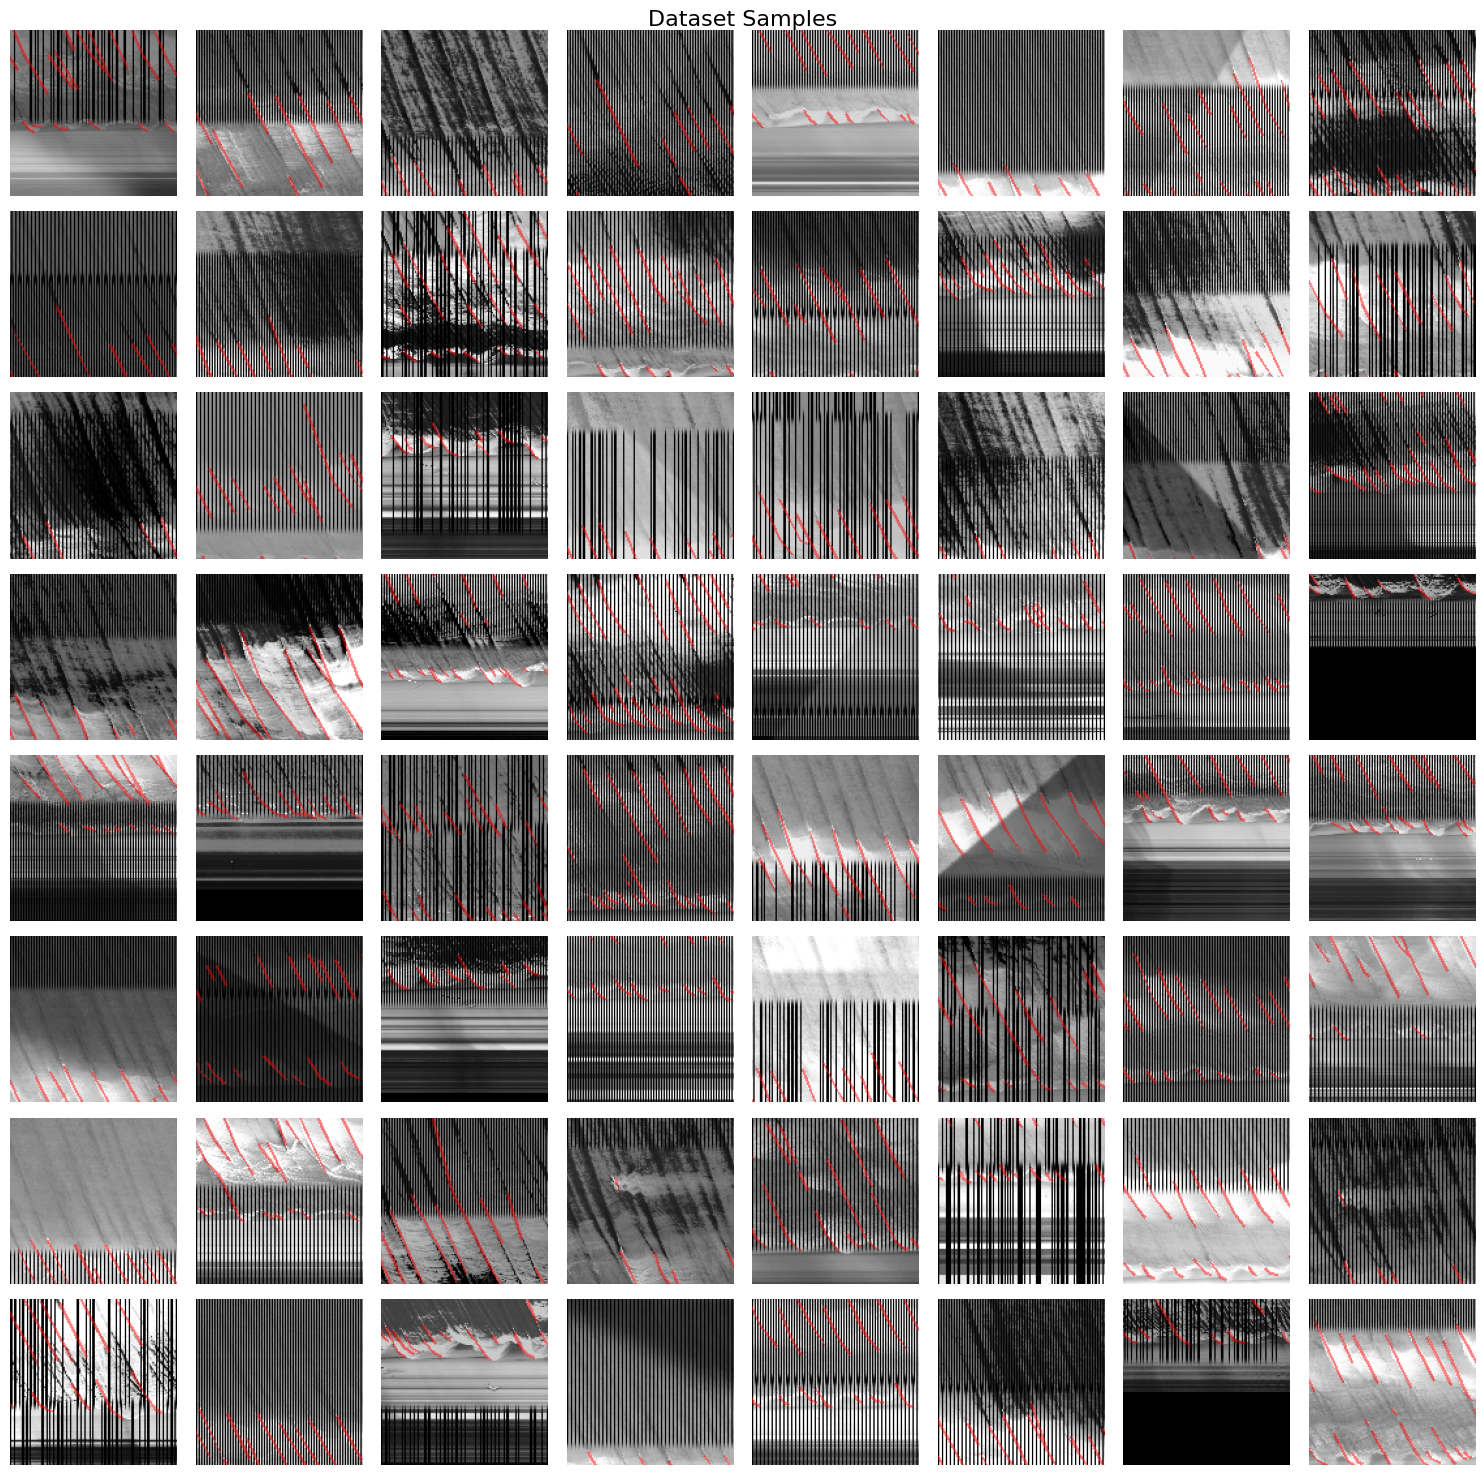

In [24]:
plot_dataset_grid(dataloaders_missing['train'].dataset, 64, indices=np.arange(0, 64))
plt.show()

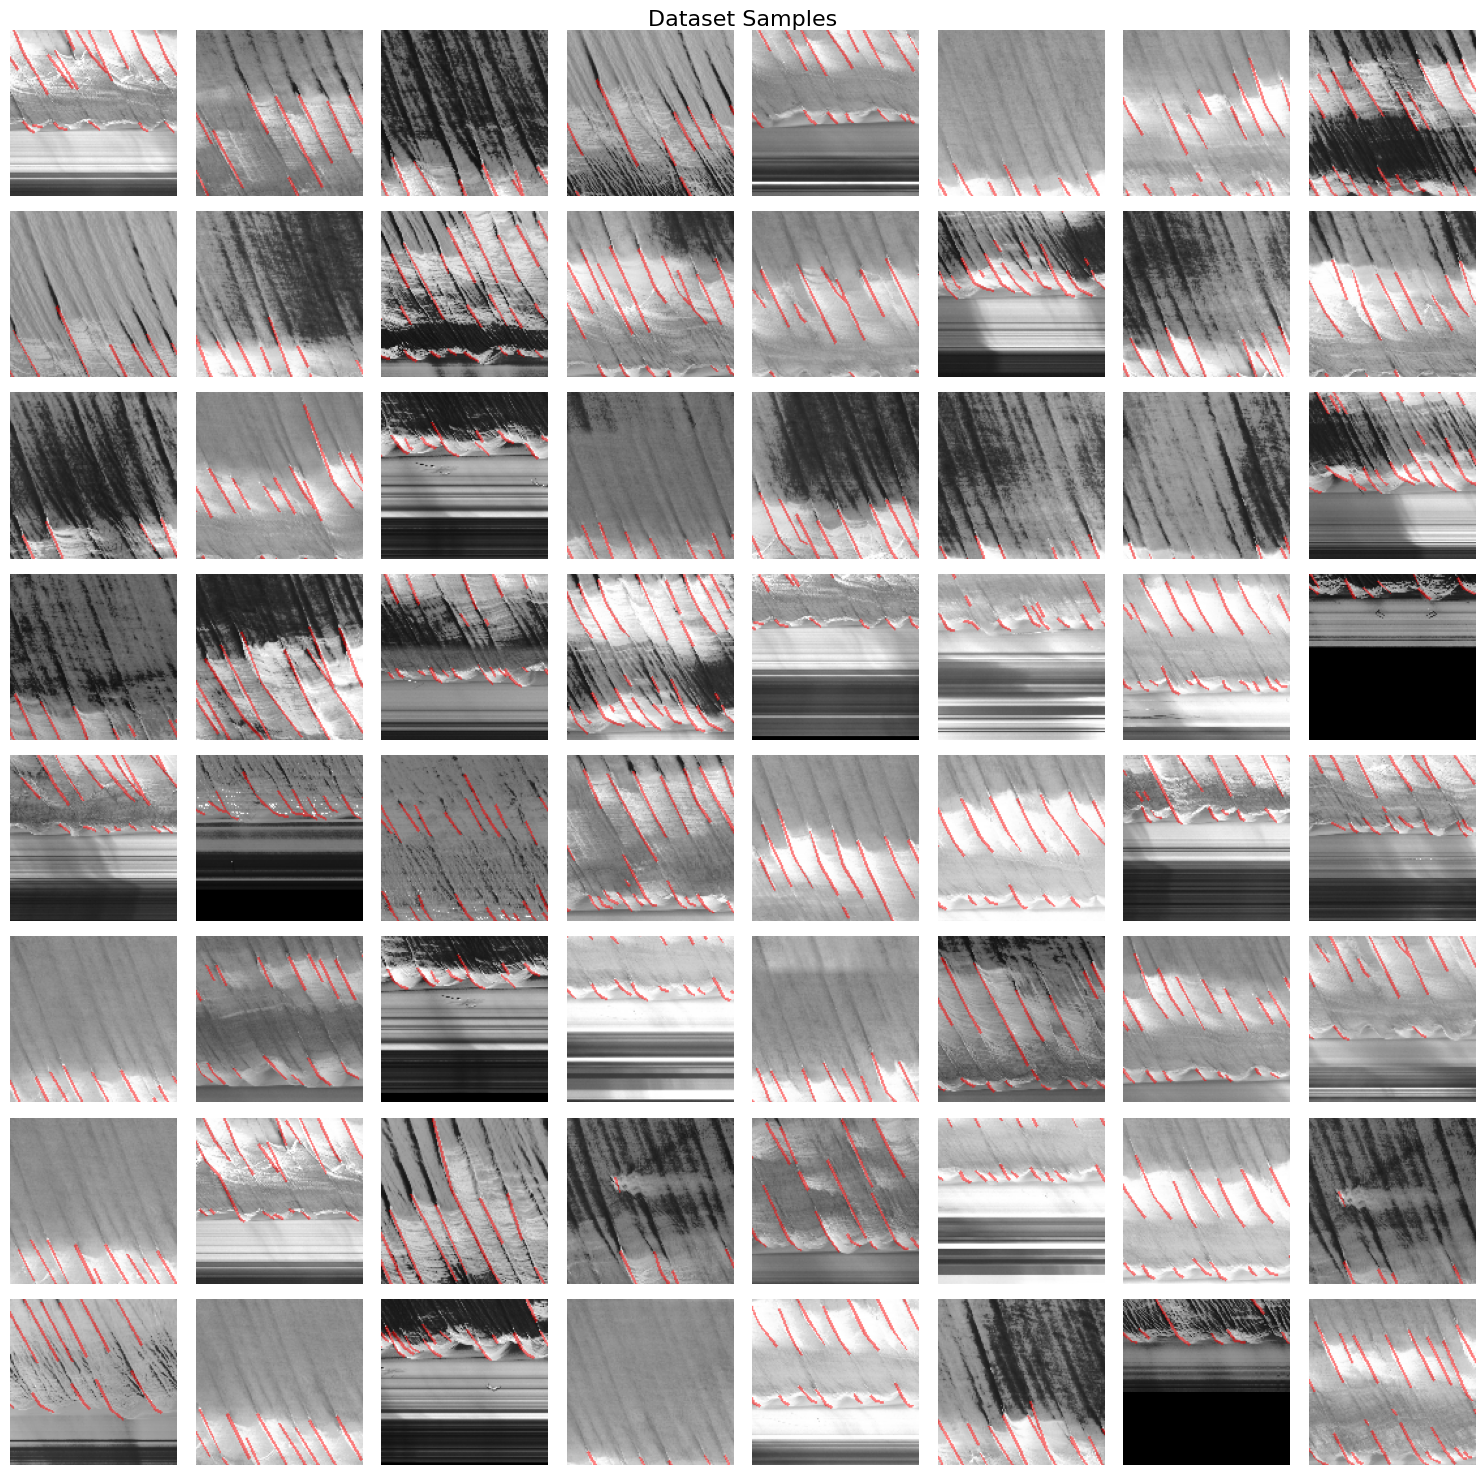

In [25]:
plot_dataset_grid(dataloaders['train'].dataset, 64, indices=np.arange(0, 64))

In [41]:
def visualize_prediction(input_img, true_mask, pred_mask, epoch):
    # Convert tensors to numpy arrays
    input_img = input_img.cpu().numpy().transpose(1, 2, 0)
    true_mask = true_mask.cpu().numpy()
    pred_mask = pred_mask.cpu().numpy()
    
    # Create a figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot input image
    ax1.imshow(input_img.squeeze())
    ax1.set_title('Input Image')
    ax1.axis('off')
    
    # Plot true mask
    ax2.imshow(true_mask.squeeze(), cmap='gray')
    ax2.set_title('True Mask')
    ax2.axis('off')
    
    # Plot predicted mask
    ax3.imshow(pred_mask.squeeze(), cmap='gray')
    ax3.set_title(f'Predicted Mask (Epoch {epoch})\nMin: {pred_mask.min():.3f}, Max: {pred_mask.max():.3f}')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close()


In [65]:
from collections import defaultdict
import torch.nn.functional as F

import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, dataloaders, optimizer, scheduler, start_epoch=0, num_epochs=200):
    l = []
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    for epoch in range(start_epoch, num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                for param_group in optimizer.param_groups:
                    print("LR", param_group['lr'])

                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                
                    # Note: No Boundary Loss
                    loss = calc_loss(outputs, labels, metrics, epoch, start_boundary_epoch=20, max_boundary_weight=0.2, start_discriminative_epoch=20, max_discriminative_weight=0.2)


                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        scheduler.step()
                        
                
                    if phase=='val' and False:
                        idx = np.random.randint(inputs.size(0))
                        visualize_prediction(
                            inputs[idx],
                            labels[idx],
                            torch.sigmoid(outputs).detach()[idx, 0],
                            epoch
                        )

                
                # statistics
                epoch_samples += inputs.size(0)
            
            if phase == 'train':
                train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                train_metrics['focal'].append(metrics['focal']/epoch_samples)
                train_metrics['dice'].append(metrics['dice']/epoch_samples)
                train_metrics['disc'].append(metrics['disc']/epoch_samples)
                train_metrics['loss'].append(loss.detach().cpu())
                
            if phase == 'val':
                validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                validation_metrics['loss'].append(loss.detach().cpu())


            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            
            # # deep copy the model
            # if phase == 'val' and epoch_loss < best_loss:
            #     print("saving best model")
            #     best_loss = epoch_loss
            #     best_model_wts = copy.deepcopy(model.state_dict())
            #     torch.save(model.state_dict(), f'training_checkpoint_model4_epoch{epoch}_{datetime.date.today().strftime('%Y%m%d')}.pt')


        if phase == 'val':
            l.append(epoch_loss)

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))


    # load best model weights
    # model.load_state_dict(best_model_wts)
    return model, l, train_metrics, validation_metrics

Epoch 0/49
----------
LR 0.0005
train: focal: 0.074966, dice: 0.935227, loss: 0.505097, boundary: 0.000000, disc: 0.000000
val: focal: 0.031675, dice: 0.933544, loss: 0.482609, boundary: 0.000000, disc: 0.000000
0m 2s
Epoch 1/49
----------
LR 0.001
train: focal: 0.025517, dice: 0.937681, loss: 0.481599, boundary: 0.000000, disc: 0.000000
val: focal: 0.740431, dice: 0.996056, loss: 0.868244, boundary: 0.000000, disc: 0.000000
0m 2s
Epoch 2/49
----------
LR 0.0015
train: focal: 0.717938, dice: 0.996986, loss: 0.857462, boundary: 0.000000, disc: 0.000000
val: focal: 0.031837, dice: 0.930443, loss: 0.481140, boundary: 0.000000, disc: 0.000000
0m 2s
Epoch 3/49
----------
LR 0.002
train: focal: 0.037494, dice: 0.934218, loss: 0.485856, boundary: 0.000000, disc: 0.000000
val: focal: 0.051984, dice: 0.932210, loss: 0.492097, boundary: 0.000000, disc: 0.000000
0m 2s
Epoch 4/49
----------
LR 0.0025
train: focal: 0.052153, dice: 0.936454, loss: 0.494303, boundary: 0.000000, disc: 0.000000
val: fo

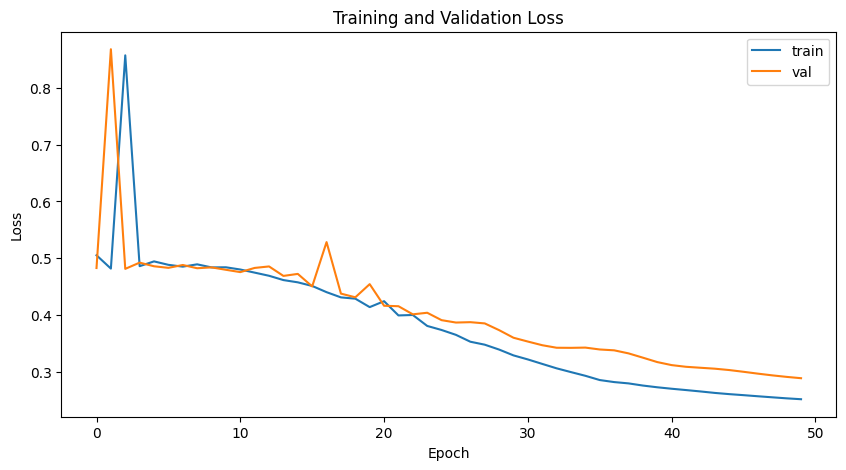

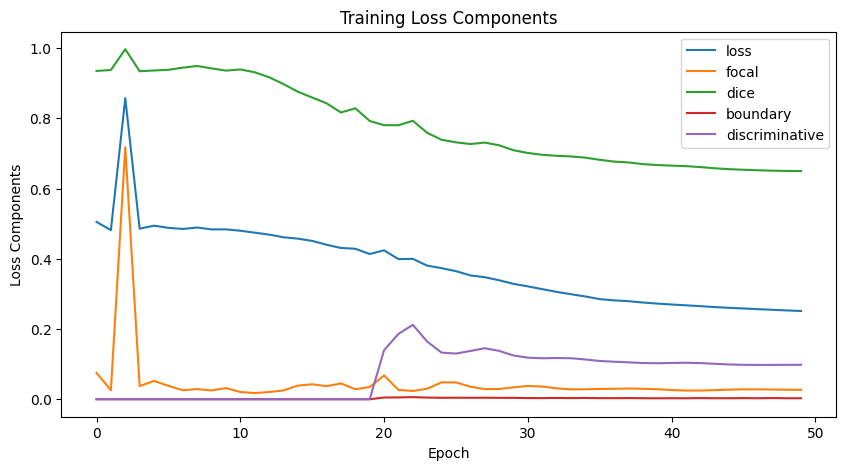

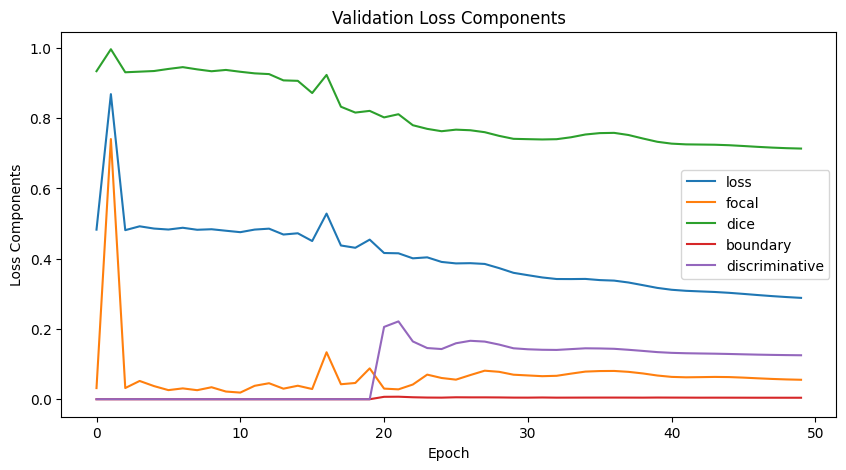

In [73]:
from loss import *

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

num_class = 1
model = ResNetUNet(num_class).to(device)
model_missing = ResNetUNet(num_class).to(device)


optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)

epochs = 50

from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(optimizer_ft, 
                       max_lr=5e-3,  # Increased from 1e-3
                       epochs=epochs,    # Train longer
                       steps_per_epoch=len(dataloaders_missing['train']),
                       div_factor=10, # Smaller div_factor for higher starting LR
                       final_div_factor=1e2, # Less aggressive final LR reduction
                       pct_start=0.2,  # Shorter warmup
                       anneal_strategy='linear') # Linear annealing


# model_missing, loss, train_metrics, val_metrics = train_model(model, dataloaders_missing, optimizer_ft, scheduler, num_epochs=epochs)
model_missing = model
model, loss, train_metrics, val_metrics = train_model(model, dataloaders_missing, optimizer_ft, scheduler, num_epochs=epochs)
torch.save(model.state_dict(), f'missing_data_experiment_wo_missing_annotation{datetime.date.today().strftime('%Y%m%d')}.pt')
# torch.save(model_missing.state_dict(), f'missing_data_experiment_w_missing_annotation{datetime.date.today().strftime('%Y%m%d')}.pt')

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Training Loss Components')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Validation Loss Components')
plt.legend()

0.050542943
0.0729459
0.02858297
0.04440499
0.029619593


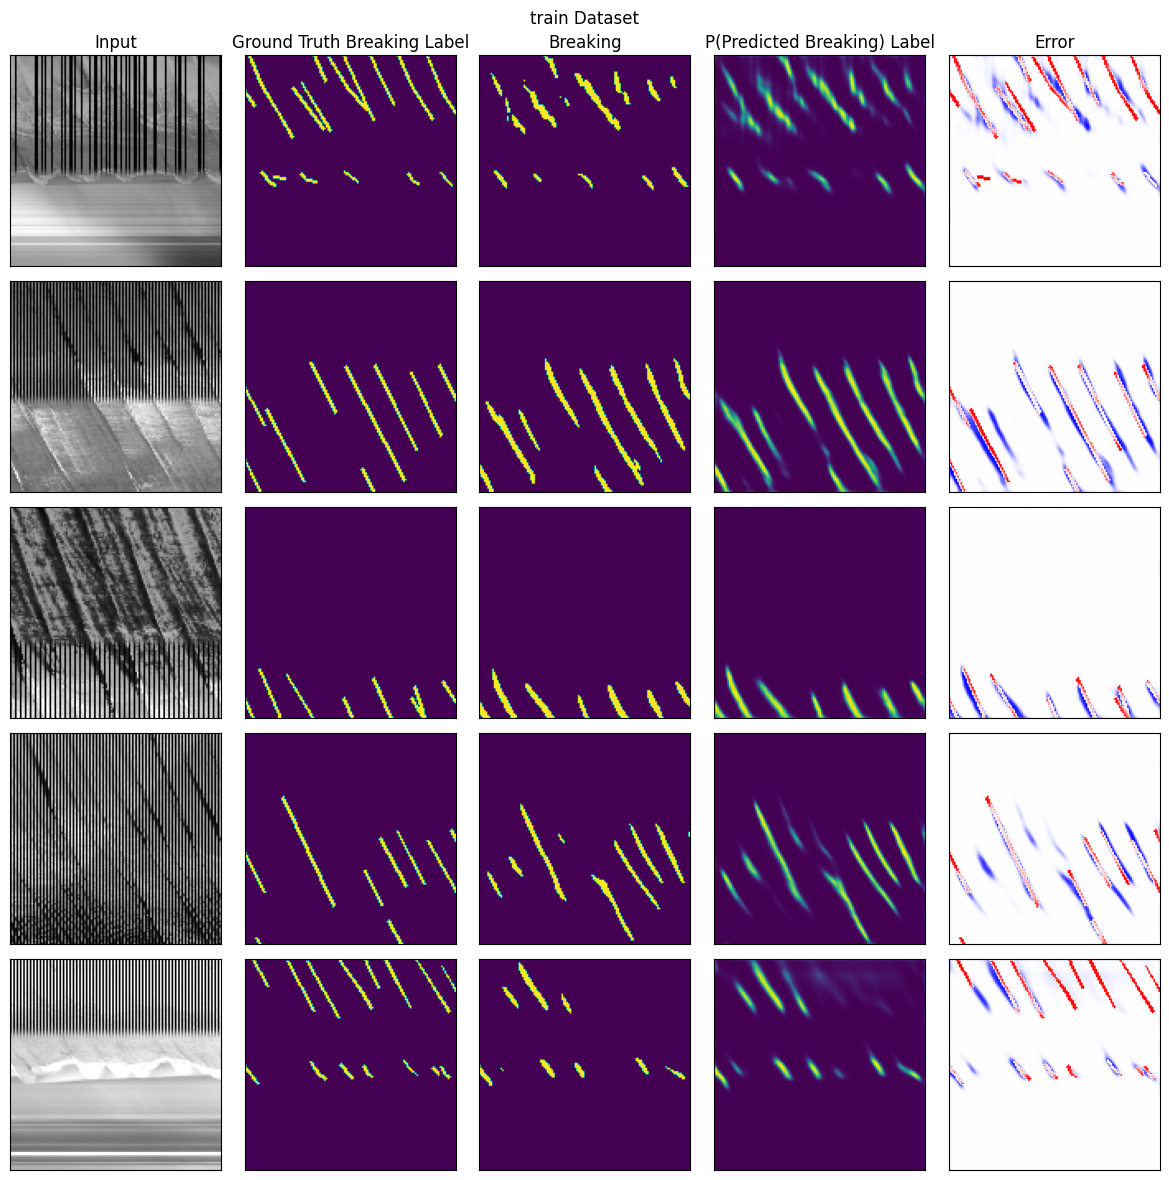

In [69]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='train'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders_missing[d].dataset[idx]
    pred = F.sigmoid(model_missing(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    print(pred.mean())
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis')#, vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset model trained w/ missing data annotation')
plt.tight_layout()
plt.show()


0.014598615
0.051908083
0.026377872
0.037320517
0.063324064


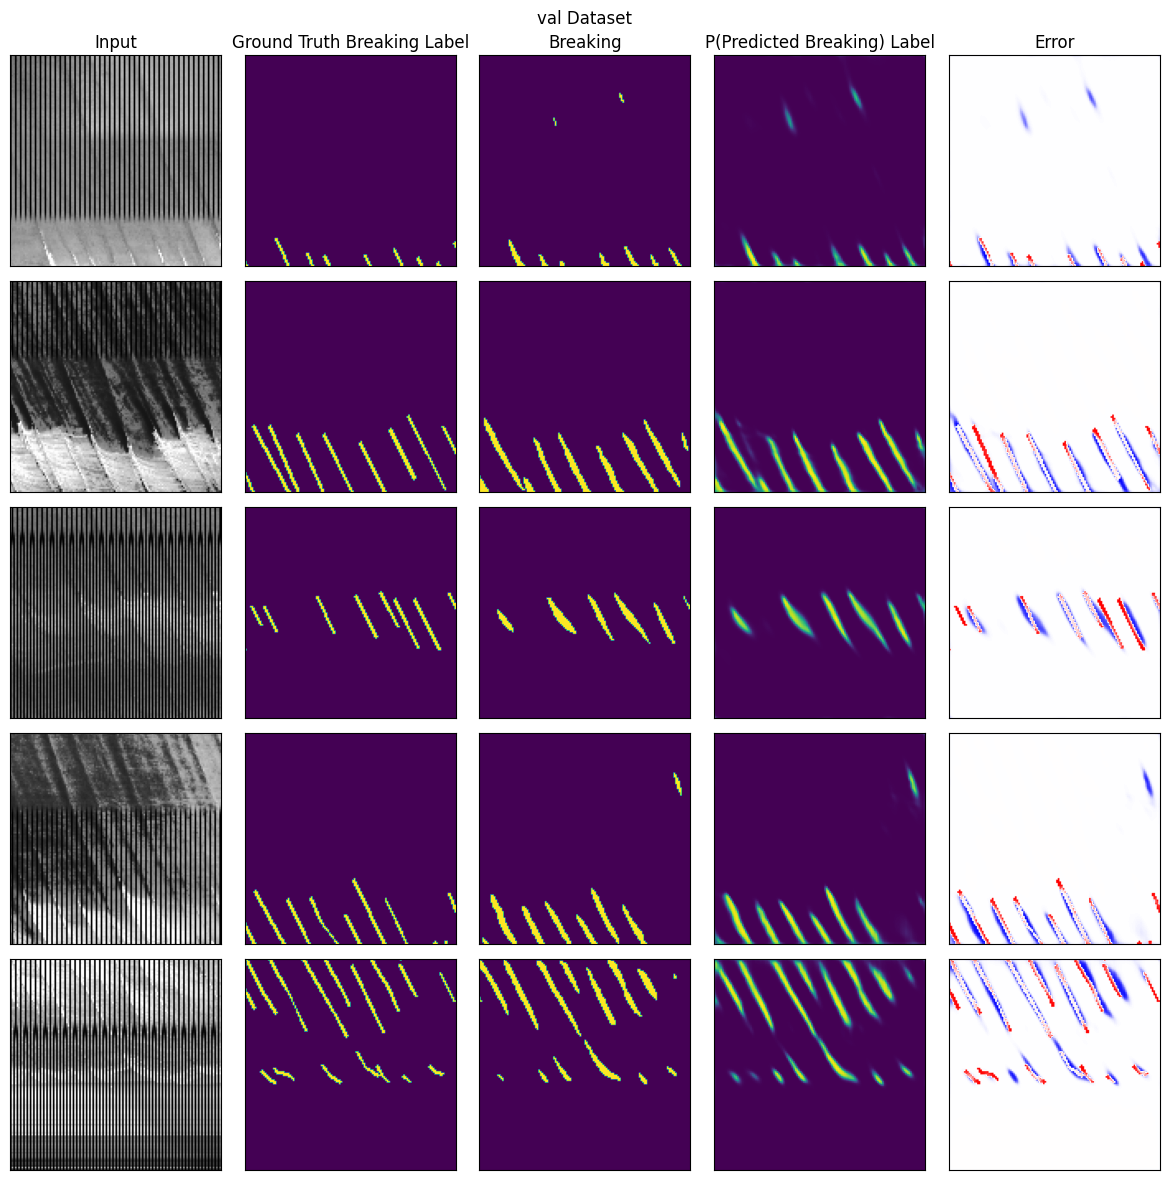

In [70]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='val'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders_missing[d].dataset[idx]
    pred = F.sigmoid(model_missing(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    print(pred.mean())
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis')#, vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset model trained w/missing data annotation')
plt.tight_layout()
plt.show()


0.009658787
0.040798005
0.026013501
0.030971263
0.053797398


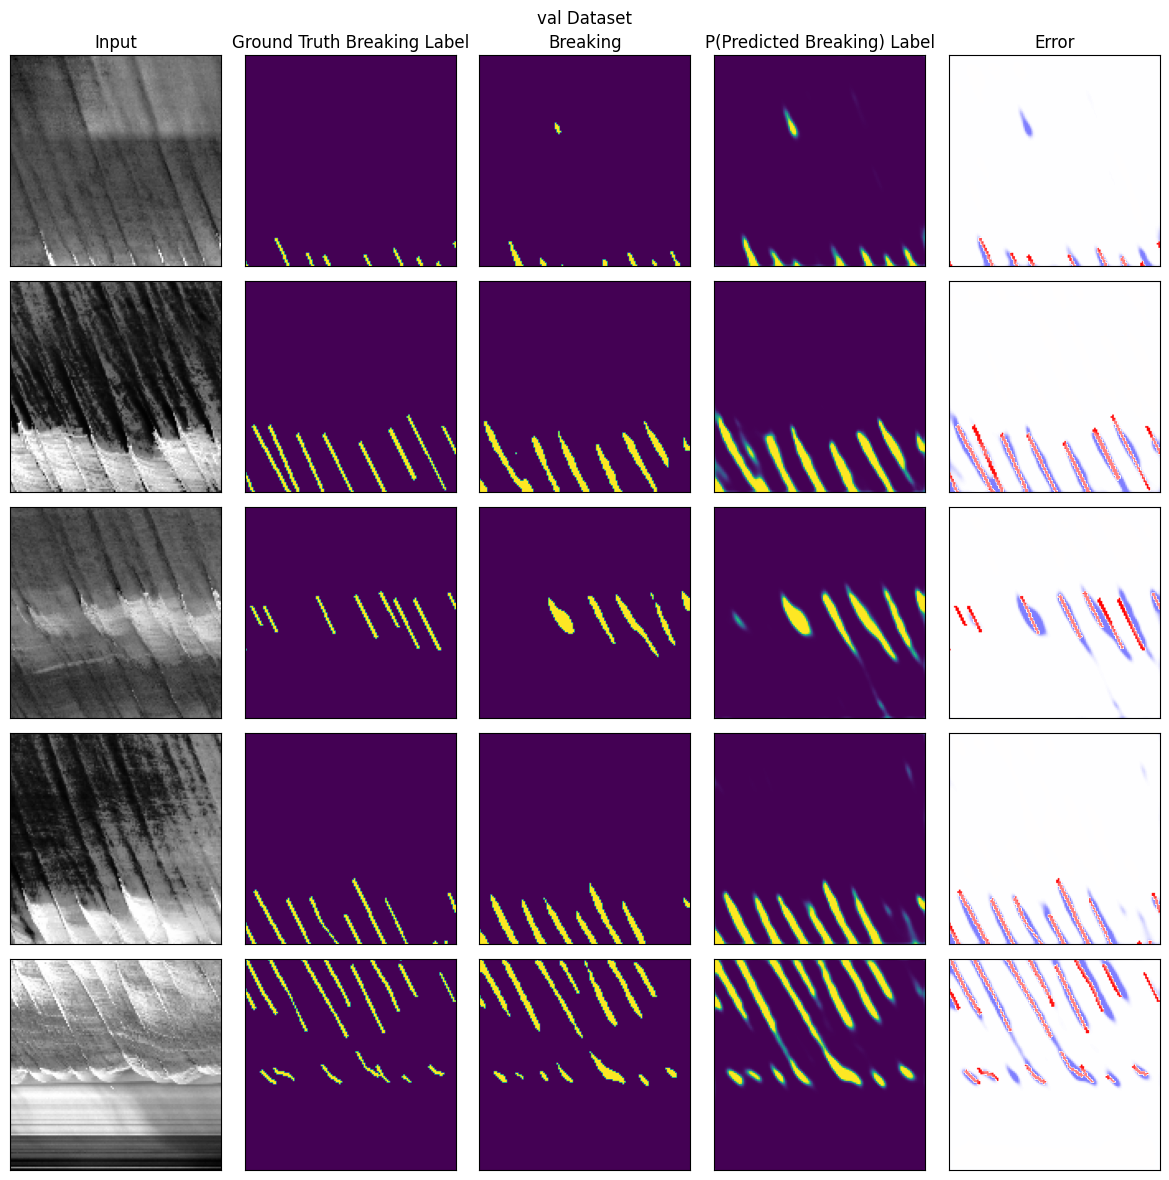

In [74]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='val'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    print(pred.mean())
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis')#, vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset')
plt.tight_layout()
plt.show()


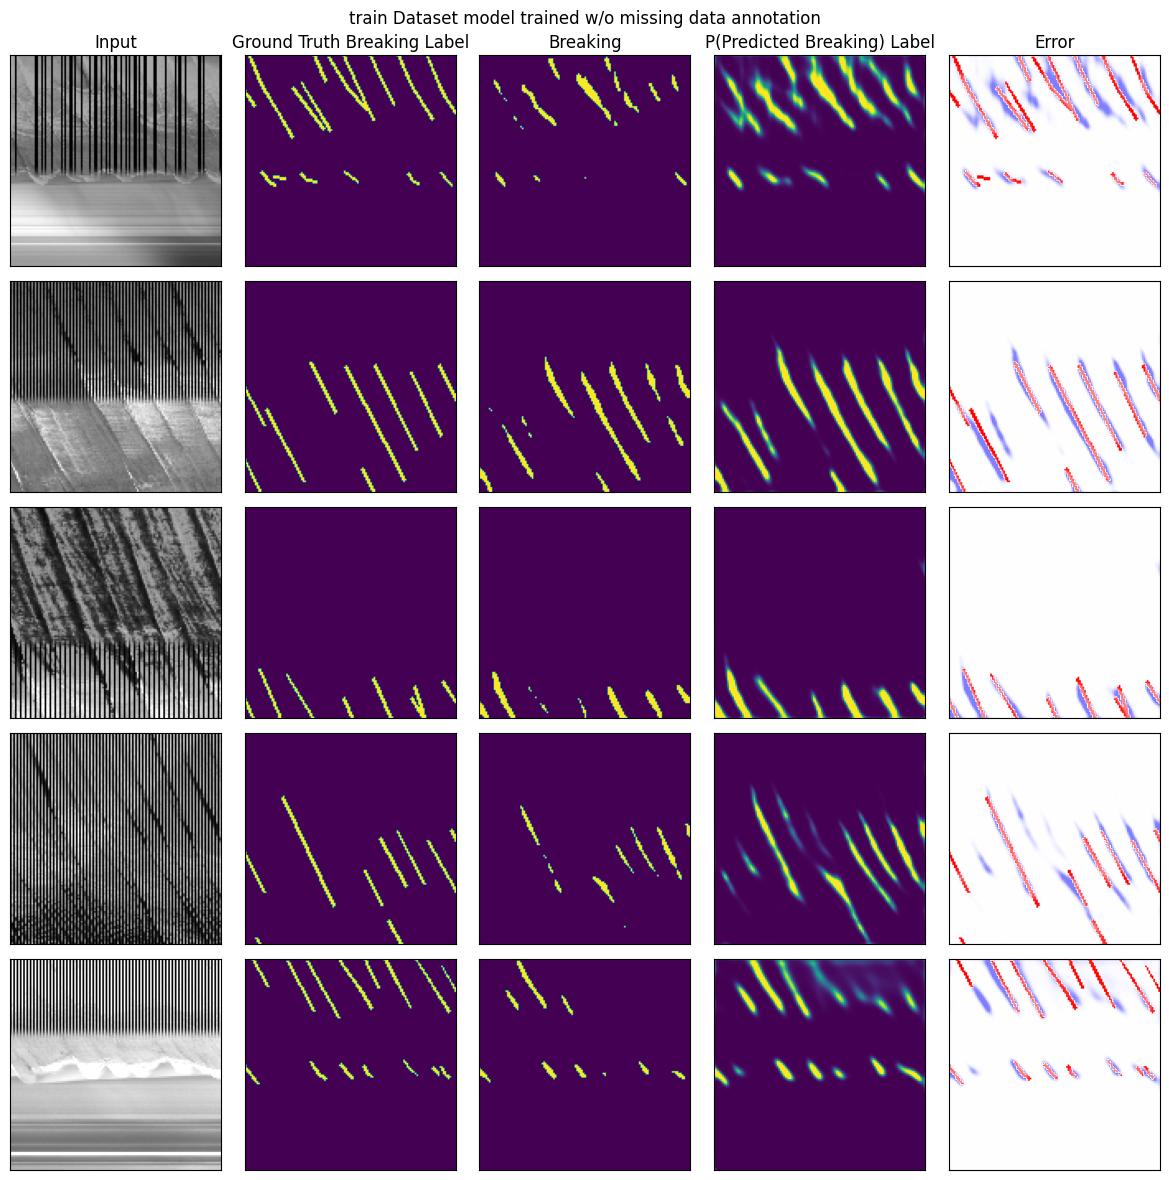

In [76]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='train'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders_missing[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis')#, vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset model trained w/o missing data annotation')
plt.tight_layout()
plt.show()
